# Dictionary Learning w/t MOD

In this notebook we show how to do dictionary learning using the "modified MOD algorithm" presented [here](https://arxiv.org/abs/2511.14147). Let $D$ be the dictionary we would like to recover. First, we use `mod_sample!` to collect several rough approximations to $D$. Then, we use k-medioids clustering to "average" these sample recoveries.

First, some miscellanious setup.

In [1]:
using Pkg
Pkg.activate(".")

using LinearAlgebra, StaticArrays, Random, SparseArrays
using StatsBase
using Base.Threads
using CUDA, Adapt, KernelAbstractions, GPUArrays
using Plots, StatsPlots, JLD2
using Clustering, Graphs
using DictionaryLearning
using NPZ

include("../debug.jl")

# plot theme
theme(:rose_pine)

# choose backend
back = CUDA.functional() ? CUDABackend() : CPU()

# set threads
BLAS.set_num_threads(nthreads())

println("$INF backend: $back")
println("$INF # threads: $(nthreads())")
;

  Activating project at `~/DictionaryLearning/examples/dictionary-learning`

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


[INF] backend: CUDABackend(false, false)
[INF] # threads: 32


Now choose the dictionary that will be learned. Here we use the Green's matrix of the Foldy-Lax model. See the relevant example for how this is generated. Later, the dictionary is assumed to have normalized columns.

In [2]:
@load "../../temp/fl-example/fls.jld2" fls
D = fls.G

# normalize columns
normalize!.(eachcol(D))

;

Specify how the dictionary should be sampled and how many approximate recoveries should be performed.

In [3]:
# how many random observations
n = 10000

# sparsity of those observations
s = 4

# how many approximate recoveries
nsamples = 5

# whether to precondition
do_precond = true

;

Move everything to the appropriate backend and compute the observations.

In [4]:
# move to backend
D = adapt(back, D)
m, k = size(D)

println("$INF m = $m")
println("$INF k = $k")

# generate observations
X = adapt(back, gen_sparse_samples(eltype(D), k, n, s))
;

[INF] m = 255
[INF] k = 169


In [ ]:
if do_precond
    println(@elapsed begin W, Winv = get_white(D*X, k, s) end)
    println(@elapsed begin W2, Winv2 = get_white_fast(D*X, k, s) end)
else
    W = adapt(back, I(m))
    Winv = adapt(back, I(m))
end

D_white = W2 * D
Y_white = D_white*X

;

0.217435896
0.012601373


In [8]:
println(svdvals(W))
println(svdvals(W2))

[1.5611302925979907e7, 2.286238117317863e6, 1.642668938544405e6, 476457.77226135717, 387985.9392793443, 299780.33498022973, 119801.41277860892, 92491.61388121545, 61533.57830459291, 47597.32515137149, 33806.25418091232, 24258.46661631049, 17535.64455846434, 13202.592021171826, 11711.05435665811, 7634.222046055114, 6544.921848110292, 6147.392152132505, 4633.6080263193935, 3812.004370094045, 3321.485971523618, 2457.9023846814566, 2177.8284989900308, 1887.7086297282071, 1479.068741129539, 1260.288602991381, 1169.348137333886, 1012.3409801706316, 916.8086714374252, 823.0334948499686, 683.3492822072253, 559.8823470600329, 545.652781563753, 471.50155697745316, 395.6531617063714, 365.6630117212852, 309.4356064015888, 275.86445265789456, 262.67025334118586, 225.32157753352516, 202.80976642223067, 186.26377484328302, 176.04986037747372, 165.46523947869713, 145.58989928074212, 138.8130119623671, 125.34225481356044, 113.33173829865781, 109.20615141147057, 92.27719378061013, 88.7591617259788, 81.8

[INF] maximum covariance before whitening: 0.8453363050051931
[INF] maximum covariance after whitening: 0.07661761669399969


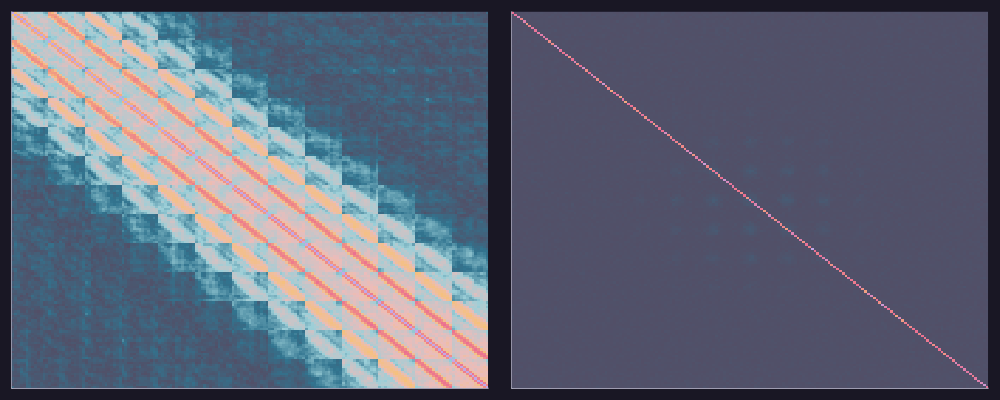

In [35]:
let
    mc = max_offdiag_coh(D)
    println("$INF maximum covariance before whitening: $mc")

    mc_white = max_offdiag_coh(D_white)
    println("$INF maximum covariance after whitening: $mc_white")
end

# force GPU cleanup
if back == CUDABackend()
    GC.gc()
    CUDA.reclaim()
end

p1 = heatmap(adapt(CPU(), abs.(D'*D)), yflip=true, legend=false, xticks=false, yticks=false)
p2 = heatmap(adapt(CPU(), abs.(D_white'*D_white)), yflip=true, legend=false, xticks=false, yticks=false)

plot(p1, p2, layout=(1,2), size=(1000, 400))

Before collecting samples, we need to specify settings for collecting the sample recoveries. The sparsity regularization parameter and step size can be finicky and probably needs to be tuned for different dictionaries. If the error does not converge, try decreasing the step size or changing the regularization so that the resulting sparsity is closer to $s$. If you get an error about being row-rank defficient, you probably need to provide more observations or lower the regularization. Why this algorithm works, and the relationship between the sparsity, error, step size, and regularization parameter is not well understood.

In [7]:
msss = MODSampleStruct[]

for _ in 1:nsamples
    push!(msss, 
        MODSampleStruct(
            Y_white, k, 
            0.25,                   # sparsity regularization parameter
            eps=1e-2,               # termination error threshold
            dt=0.1,                 # step size
            max_iters=1000,         # maximum allowed iterations
            sparse_ls_cutoff=0.1    # sparsity to start using conjugate gradient
        )
    )
end
;

Now, actually collect the approximate dictionaries.

In [8]:
let
    msws = MODSampleWorkStruct(msss[1])

    for (i,mss) in enumerate(msss)
        println("$INF sample $i/$nsamples")
        try
            mod_sample!(mss, msws)
        catch err
            println(typeof(err))
            if isa(err, SingularException)
                @warn "Sample $i became rank-defficient"
            else
                rethrow()
            end
        end
    end
end

[INF] sample 1/5
[INF] sample 2/5
[INF] sample 3/5
[INF] sample 4/5
[INF] sample 5/5


[INF] mean L1 errors of final iterations:  0.009875998012700773
[INF] mean sparsities of final iterations: 6.5312999215686265


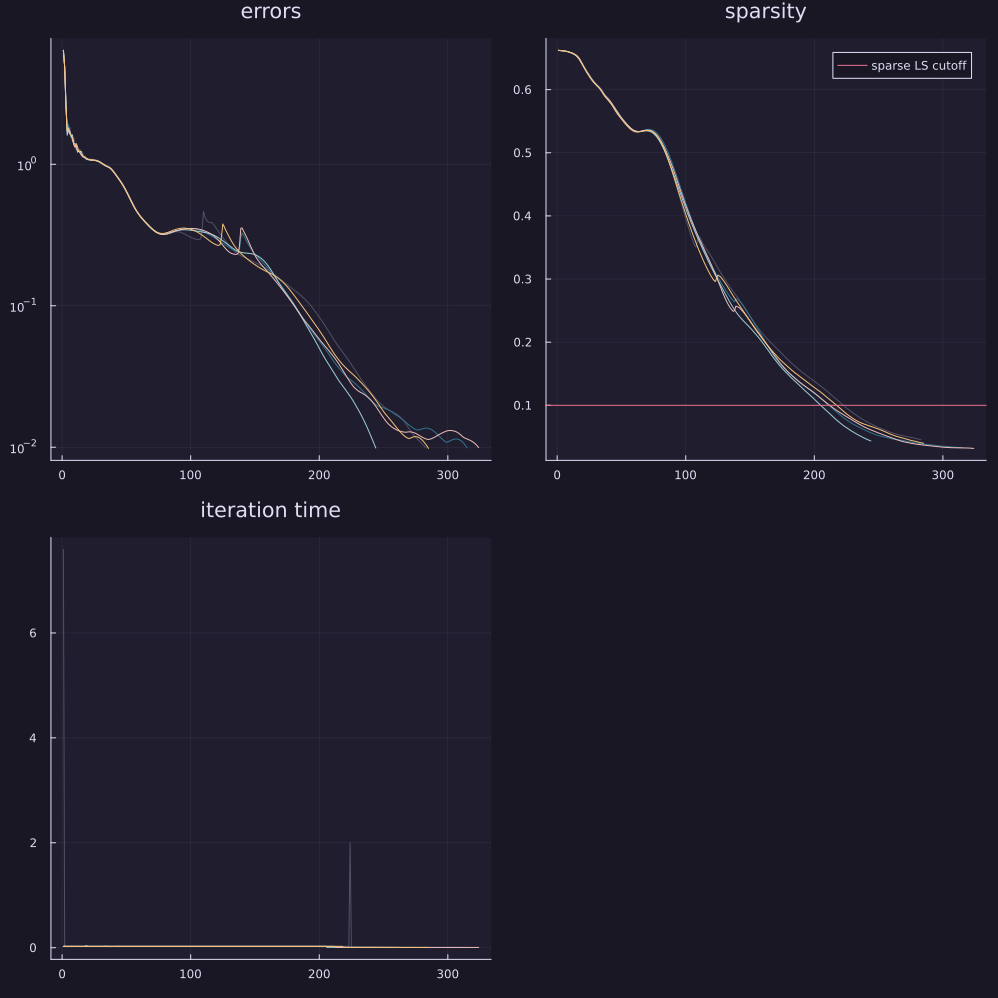

In [9]:
println("$INF mean L1 errors of final iterations:  $(mean(last.(getproperty.(msss, :err_hist))))")
println("$INF mean sparsities of final iterations: $(k*mean(last.(getproperty.(msss, :sparsity_hist))))")

p1 = plot(getproperty.(msss, :err_hist), yscale=:log10, label=:none, title="errors")
p2 = plot(getproperty.(msss, :sparsity_hist), label=:none, title="sparsity")
hline!([msss[1].sparse_ls_cutoff], label="sparse LS cutoff")
p3 = plot(getproperty.(msss, :elap_hist), label=:none, title="iteration time")

plot(p1, p2, p3, layout=(2, 2), size=(1000, 1000))

Cluster columns of the apprimxate recoveries to get a more accurate dictionary. Then align the resulting dictionary with the truth and measure how accurate the reconstruction is.

In [ ]:
# allocate space for recoverd dictionary
Dr_white = similar(D)

# do clustering
mod_cluster!(Dr_white, msss, min_cluster_size=10)

Dr = Winv * Dr_white

# align to true dictionary
align_dict!(D, Dr)

# measure lowest coherence between aligned columns
println("$INF minimum paired coherence: $(minimum(abs.(diag(D' * Dr))))")

# measure lowest coherence between aligned columns
println("$INF relative F-norm error: $(norm(D - Dr)/norm(D))")

[INF] minimum paired coherence: 0.9923016409820125
[INF] relative F-norm error: 0.024355020712904286


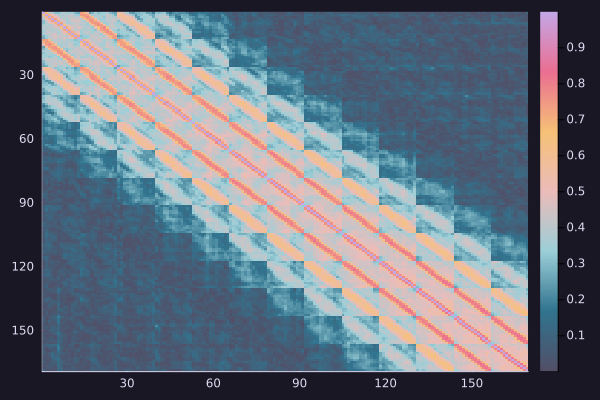

In [13]:
heatmap(adapt(CPU(), abs.(D'*Dr)), yflip=true)